<a href="https://colab.research.google.com/github/miaowangcissy/animal_behavior_analysis_in_python/blob/main/day4_state_discovery/Day4_0_eigenanalysis_explanation_standalone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Day4 0 Eigenanalysis: What Eigenvalues Tell Us About Timescales

This is the key insight of the entire Markov chain approach. We will build it step by step, starting from a concrete example that you can compute by hand.

### Step 1: What does the transition matrix *do*?

Suppose we have 2 states (Left and Right well), and the transition matrix is:

$$P = \begin{pmatrix} 0.9 & 0.1 \\ 0.2 & 0.8 \end{pmatrix}$$

This says: if the particle is in the Left well, it has a 90% chance of staying (row 1, col 1) and 10% chance of jumping Right (row 1, col 2). From the Right well: 20% chance of jumping Left, 80% of staying.

Now, suppose at $t=0$ the particle is definitely in the Left well:

$$\vec{p}(0) = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$$

**Question:** What is the probability distribution after 1 step? After 2 steps? After 100 steps?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
CB_COLORS = ['#0077BB', '#EE7733', '#009988', '#CC3311', '#33BBEE', '#EE3377']

# Define the transition matrix
P = np.array([[0.9, 0.1],
              [0.2, 0.8]])

p0 = np.array([1.0, 0.0])  # start in Left well

# Evolve for several steps
print("Time evolution of probability distribution:")
print(f"  t=0:   p = [{p0[0]:.4f}, {p0[1]:.4f}]")

p = p0.copy()
for t in [1, 2, 5, 10, 50, 100]:
    p_t = np.linalg.matrix_power(P.T, t) @ p0  # P^t applied to p0
    print(f"  t={t:<4d} p = [{p_t[0]:.4f}, {p_t[1]:.4f}]")

print(f"\nThe system converges to a steady state: p* ≈ [0.6667, 0.3333]")
print(f"This is the EQUILIBRIUM — no matter where you start, you end up here.")

Time evolution of probability distribution:
  t=0:   p = [1.0000, 0.0000]
  t=1    p = [0.9000, 0.1000]
  t=2    p = [0.8300, 0.1700]
  t=5    p = [0.7227, 0.2773]
  t=10   p = [0.6761, 0.3239]
  t=50   p = [0.6667, 0.3333]
  t=100  p = [0.6667, 0.3333]

The system converges to a steady state: p* ≈ [0.6667, 0.3333]
This is the EQUILIBRIUM — no matter where you start, you end up here.


### Step 2: Eigendecomposition — *why* does it converge?

To understand *why* and *how fast* the system converges, we decompose $P$ into its eigenvalues and eigenvectors.

**Recall from linear algebra:** If $P$ has eigenvalues $\lambda_1, \lambda_2$ and corresponding right eigenvectors $\vec{v}_1, \vec{v}_2$, then:

$$P \vec{v}_i = \lambda_i \vec{v}_i$$

For our $2 \times 2$ transition matrix, we solve $\det(P - \lambda I) = 0$:

$$\det \begin{pmatrix} 0.9 - \lambda & 0.1 \\ 0.2 & 0.8 - \lambda \end{pmatrix} = 0$$

$$(0.9 - \lambda)(0.8 - \lambda) - (0.1)(0.2) = 0$$

$$\lambda^2 - 1.7\lambda + 0.70 = 0$$

$$\lambda_1 = 1.0, \quad \lambda_2 = 0.7$$

Let's verify this and find the eigenvectors:

In [2]:
# Eigendecomposition of P
eigenvalues, eigenvectors = np.linalg.eig(P.T)

# Sort by descending eigenvalue
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx].real
eigenvectors = eigenvectors[:, idx].real

print("Eigendecomposition of P:")
print(f"  λ₁ = {eigenvalues[0]:.4f}")
print(f"  λ₂ = {eigenvalues[1]:.4f}")
print(f"\n  v₁ = [{eigenvectors[0,0]:.4f}, {eigenvectors[1,0]:.4f}]")
print(f"  v₂ = [{eigenvectors[0,1]:.4f}, {eigenvectors[1,1]:.4f}]")

# Normalize v1 to be a probability distribution (sum = 1)
v1_normalized = eigenvectors[:, 0] / eigenvectors[:, 0].sum()
print(f"\n  v₁ (normalized) = [{v1_normalized[0]:.4f}, {v1_normalized[1]:.4f}]")
print(f"  → This IS the steady-state distribution! (2/3 Left, 1/3 Right)")

Eigendecomposition of P:
  λ₁ = 1.0000
  λ₂ = 0.7000

  v₁ = [0.8944, 0.4472]
  v₂ = [-0.7071, 0.7071]

  v₁ (normalized) = [0.6667, 0.3333]
  → This IS the steady-state distribution! (2/3 Left, 1/3 Right)


### Step 3: Decomposing the time evolution

Here is the key step. We can write any initial distribution $\vec{p}(0)$ as a **linear combination** of the eigenvectors:

$$\vec{p}(0) = c_1 \vec{v}_1 + c_2 \vec{v}_2$$

where $c_1, c_2$ are coefficients. Since $P\vec{v}_i = \lambda_i \vec{v}_i$, applying $P$ once gives:

$$\vec{p}(1) = P \vec{p}(0) = c_1 \lambda_1 \vec{v}_1 + c_2 \lambda_2 \vec{v}_2$$

Applying $P$ again: $\vec{p}(2) = c_1 \lambda_1^2 \vec{v}_1 + c_2 \lambda_2^2 \vec{v}_2$. In general:

$$\boxed{\vec{p}(t) = c_1 \lambda_1^t \vec{v}_1 + c_2 \lambda_2^t \vec{v}_2}$$

Now look at what happens to each term as $t \to \infty$:

| Term | Value at $t$ | As $t \to \infty$ | Interpretation |
|:---|:---|:---|:---|
| $c_1 \lambda_1^t \vec{v}_1$ | $c_1 \cdot 1^t \cdot \vec{v}_1 = c_1 \vec{v}_1$ | **Stays forever** | Steady state component |
| $c_2 \lambda_2^t \vec{v}_2$ | $c_2 \cdot 0.7^t \cdot \vec{v}_2$ | **Decays to 0** | Transient deviation from equilibrium |

**This is the crucial insight:** The eigenvalue $\lambda_2 = 0.7$ controls how fast the system *forgets* its initial condition and relaxes to equilibrium. The closer $\lambda_2$ is to 1, the slower this forgetting happens.

Decomposition: p(0) = 0.7454 * v₁ + -0.4714 * v₂


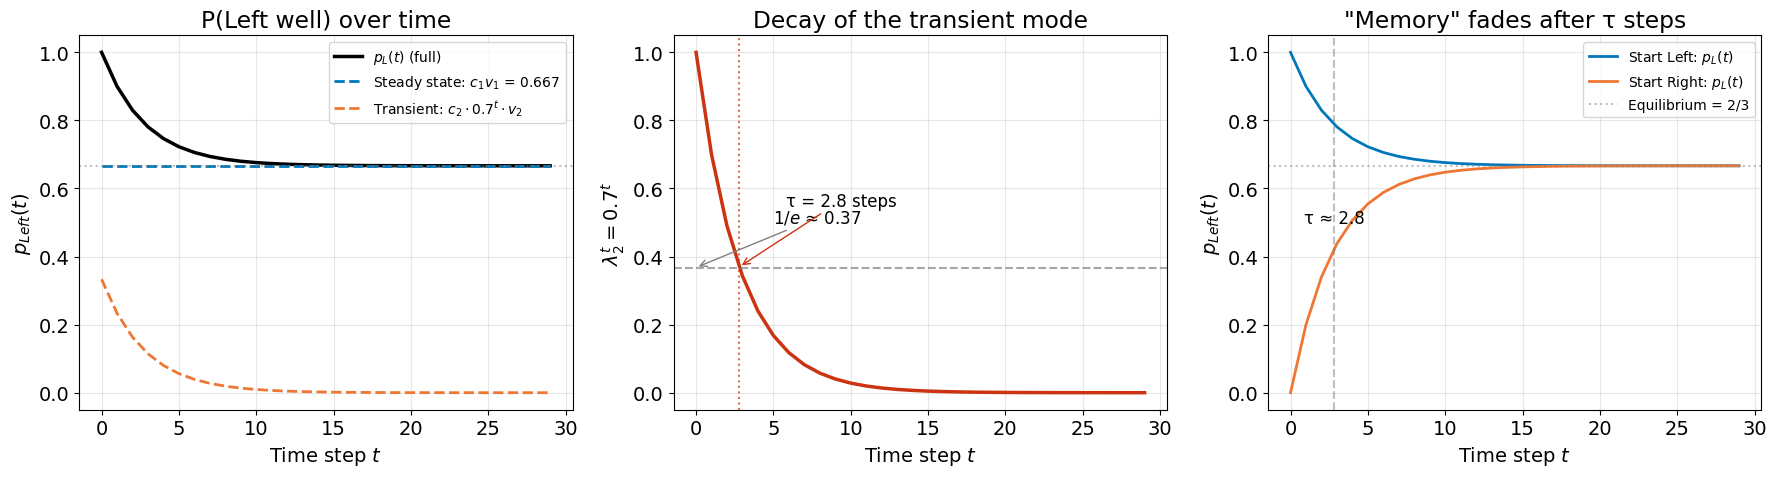


Key result: τ = -1/ln(0.7) = 2.80 steps
After ~3 steps, the system has 'forgotten' ~63% of where it started.
After ~8 steps (3τ), it has forgotten ~95% — effectively at equilibrium.


In [3]:
# Demonstrate the decomposition visually
# Decompose p(0) = [1, 0] into eigenvector basis
# Solve: c1*v1 + c2*v2 = p0
V = eigenvectors  # columns are eigenvectors
c = np.linalg.solve(V, p0)
print(f"Decomposition: p(0) = {c[0]:.4f} * v₁ + {c[1]:.4f} * v₂")

# Show how each component evolves
t_range = np.arange(0, 30)

# Full evolution
p_full = np.array([np.linalg.matrix_power(P.T, t) @ p0 for t in t_range])

# Component 1: steady state (constant)
comp1 = np.outer(np.ones_like(t_range), c[0] * V[:, 0])

# Component 2: decaying transient  
comp2 = np.outer(eigenvalues[1]**t_range, c[1] * V[:, 1])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Full probability of being in Left well
axes[0].plot(t_range, p_full[:, 0], 'k-', linewidth=2.5, label='$p_L(t)$ (full)')
axes[0].plot(t_range, comp1[:, 0], '--', color=CB_COLORS[0], linewidth=2, label=f'Steady state: $c_1 v_1$ = {c[0]*V[0,0]:.3f}')
axes[0].plot(t_range, comp2[:, 0], '--', color=CB_COLORS[1], linewidth=2, label=f'Transient: $c_2 \\cdot 0.7^t \\cdot v_2$')
axes[0].set_xlabel('Time step $t$')
axes[0].set_ylabel('$p_{Left}(t)$')
axes[0].set_title('P(Left well) over time')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].axhline(2/3, color='gray', linestyle=':', alpha=0.5)

# Middle: The decay of λ₂^t
axes[1].plot(t_range, eigenvalues[1]**t_range, linewidth=2.5, color=CB_COLORS[3])
axes[1].axhline(1/np.e, color='gray', linestyle='--', alpha=0.7)
axes[1].annotate(f'$1/e$ ≈ 0.37', xy=(0, 1/np.e), xytext=(5, 0.5),
                fontsize=12, arrowprops=dict(arrowstyle='->', color='gray'))

# Mark the relaxation time
tau = -1/np.log(eigenvalues[1])
axes[1].axvline(tau, color=CB_COLORS[3], linestyle=':', alpha=0.7)
axes[1].annotate(f'τ = {tau:.1f} steps', xy=(tau, 0.37), xytext=(tau+3, 0.55),
                fontsize=12, arrowprops=dict(arrowstyle='->', color=CB_COLORS[3]))

axes[1].set_xlabel('Time step $t$')
axes[1].set_ylabel('$\\lambda_2^t = 0.7^t$')
axes[1].set_title('Decay of the transient mode')
axes[1].grid(alpha=0.3)

# Right: "Memory" interpretation
# Start from two different initial conditions
p0_left = np.array([1.0, 0.0])    # start Left
p0_right = np.array([0.0, 1.0])   # start Right

p_left = np.array([np.linalg.matrix_power(P.T, t) @ p0_left for t in t_range])
p_right = np.array([np.linalg.matrix_power(P.T, t) @ p0_right for t in t_range])

axes[2].plot(t_range, p_left[:, 0], linewidth=2, color=CB_COLORS[0], label='Start Left: $p_L(t)$')
axes[2].plot(t_range, p_right[:, 0], linewidth=2, color=CB_COLORS[1], label='Start Right: $p_L(t)$')
axes[2].axhline(2/3, color='gray', linestyle=':', alpha=0.5, label='Equilibrium = 2/3')
axes[2].axvline(tau, color='gray', linestyle='--', alpha=0.5)
axes[2].annotate(f'τ ≈ {tau:.1f}', xy=(tau, 0.5), fontsize=12, ha='center')
axes[2].set_xlabel('Time step $t$')
axes[2].set_ylabel('$p_{Left}(t)$')
axes[2].set_title('"Memory" fades after τ steps')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey result: τ = -1/ln(0.7) = {tau:.2f} steps")
print(f"After ~{tau:.0f} steps, the system has 'forgotten' ~63% of where it started.")
print(f"After ~{3*tau:.0f} steps (3τ), it has forgotten ~95% — effectively at equilibrium.")

### Step 4: The relaxation time formula

We just saw that eigenvalue $\lambda_2 = 0.7$ decays as $0.7^t$. We want to know: **after how many steps has this decayed to $1/e$?**

We solve $\lambda^t = e^{-1}$:

$$\lambda^t = e^{-1}$$
$$t \ln(\lambda) = -1$$
$$\boxed{\tau = \frac{-1}{\ln(\lambda)}}$$

**Worked examples:**

| $\lambda$ | $\ln(\lambda)$ | $\tau = -1/\ln(\lambda)$ | Physical meaning |
|:---:|:---:|:---:|:---|
| 0.99 | -0.01 | **100 steps** | Very slow decay → long-lived mode |
| 0.9 | -0.105 | **9.5 steps** | Moderate decay |
| 0.7 | -0.357 | **2.8 steps** | Fast decay |
| 0.5 | -0.693 | **1.4 steps** | Very fast — gone in ~2 steps |
| 0.1 | -2.303 | **0.4 steps** | Almost instant decay |

**The closer $\lambda$ is to 1, the longer the mode lives.** This makes physical sense: $\lambda = 1$ means the mode never decays (steady state), and smaller $\lambda$ means faster decay.

> **Connecting to behavior:** If we find $\lambda_2 = 0.99$ for the worm's transition matrix, this means the slowest behavioral mode (e.g., the "run" vs "pirouette" switching) takes about 100 transition-matrix time steps to decorrelate. Multiplied by the actual time per step, this gives the real-world timescale in seconds.

### Step 5: Generalizing to $N$ states — what changes?

For the worm with $N = 500$ microstates, the transition matrix is $500 \times 500$, but the same logic applies:

$$\vec{p}(t) = \underbrace{c_1 \cdot 1^t \cdot \vec{v}_1}_{\text{steady state}} + \underbrace{c_2 \lambda_2^t \vec{v}_2}_{\text{slowest mode}} + \underbrace{c_3 \lambda_3^t \vec{v}_3}_{\text{2nd slowest}} + \cdots + \underbrace{c_N \lambda_N^t \vec{v}_N}_{\text{fastest mode}}$$

Each term decays at its own rate. After enough time, only the terms with the **largest** $\lambda$ values survive. 

### Step 6: The spectral gap — why it matters

Suppose the eigenvalue spectrum looks like:

$$\lambda_1 = 1.0, \quad \lambda_2 = 0.98, \quad \lambda_3 = 0.5, \quad \lambda_4 = 0.3, \quad \dots$$

There is a **gap** between $\lambda_2 = 0.98$ and $\lambda_3 = 0.5$. What does this mean?

**At intermediate times** (say $t = 10$):
- $\lambda_2^{10} = 0.98^{10} = 0.82$ → mode 2 is still **very much alive**
- $\lambda_3^{10} = 0.5^{10} = 0.001$ → mode 3 is **essentially dead**
- All modes $\lambda_4, \lambda_5, \dots$ → also dead

So at intermediate times, the system looks like it only has **two effective states** (determined by the sign of eigenvector 2), even though it really has 500 microstates!

This is exactly the **timescale separation** that lets us identify runs and pirouettes:
- **Fast timescale** ($\tau_3, \tau_4, \dots$): transitions *within* runs or *within* pirouettes
- **Slow timescale** ($\tau_2$): switching *between* runs and pirouettes

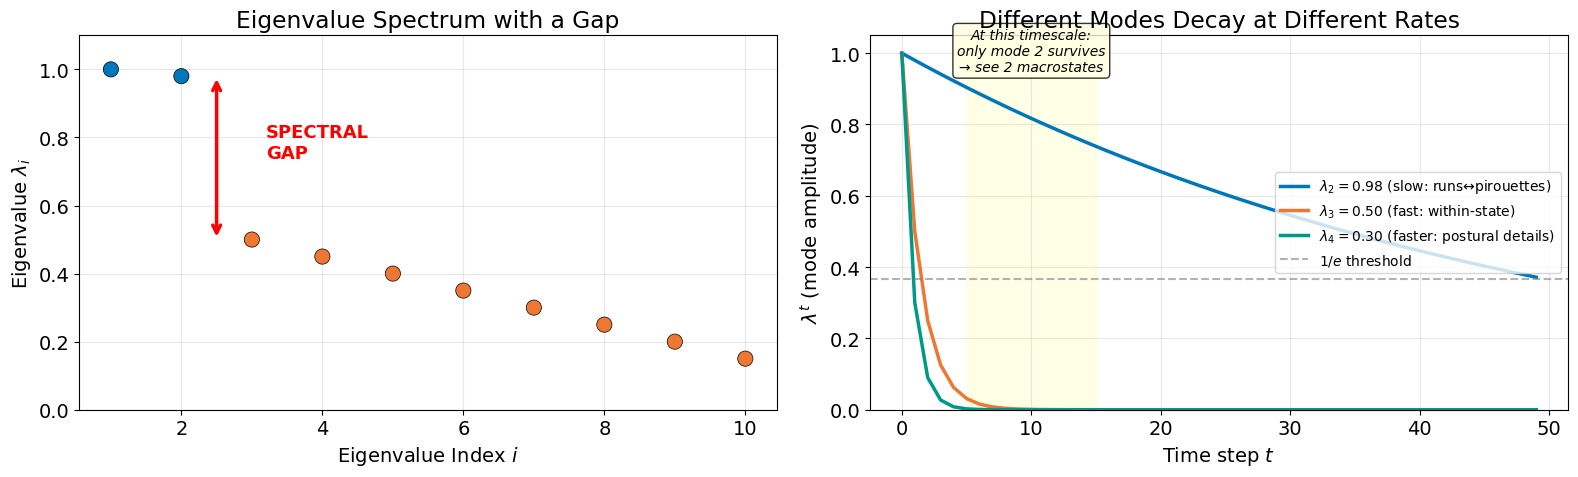

KEY INSIGHT:
At intermediate times (yellow region), λ₂ is still alive but λ₃, λ₄,... are dead.
→ The system looks like it has only 2 states (the macrostates).
→ This is why eigenvector 2 naturally splits behavior into runs vs pirouettes!


In [4]:
# Visual demonstration of spectral gap with 500-state system
# Let's create a cartoon eigenvalue spectrum

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: eigenvalue spectrum with gap
lambdas = np.array([1.0, 0.98, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15])
axes[0].scatter(range(1, len(lambdas)+1), lambdas, s=120, 
                color=[CB_COLORS[0] if i < 2 else CB_COLORS[1] for i in range(len(lambdas))],
                edgecolors='k', linewidths=0.5, zorder=3)

# Annotate the gap
axes[0].annotate('', xy=(2.5, 0.98), xytext=(2.5, 0.5),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2.5))
axes[0].text(3.2, 0.74, 'SPECTRAL\nGAP', fontsize=13, color='red', fontweight='bold')

axes[0].set_xlabel('Eigenvalue Index $i$')
axes[0].set_ylabel('Eigenvalue $\\lambda_i$')
axes[0].set_title('Eigenvalue Spectrum with a Gap')
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 1.1])

# Right: decay of each mode over time
t = np.arange(0, 50)
for i, (lam, label) in enumerate(zip([0.98, 0.5, 0.3], 
    ['$\\lambda_2 = 0.98$ (slow: runs↔pirouettes)', 
     '$\\lambda_3 = 0.50$ (fast: within-state)',
     '$\\lambda_4 = 0.30$ (faster: postural details)'])):
    axes[1].plot(t, lam**t, linewidth=2.5, label=label, color=CB_COLORS[i])

axes[1].axhline(1/np.e, color='gray', linestyle='--', alpha=0.6, label='$1/e$ threshold')

# Shade the "intermediate time" window
axes[1].axvspan(5, 15, alpha=0.1, color='yellow')
axes[1].text(10, 0.95, 'At this timescale:\nonly mode 2 survives\n→ see 2 macrostates', 
            ha='center', fontsize=10, style='italic',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

axes[1].set_xlabel('Time step $t$')
axes[1].set_ylabel('$\\lambda^t$ (mode amplitude)')
axes[1].set_title('Different Modes Decay at Different Rates')
axes[1].legend(fontsize=10, loc='right')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("KEY INSIGHT:")
print("At intermediate times (yellow region), λ₂ is still alive but λ₃, λ₄,... are dead.")
print("→ The system looks like it has only 2 states (the macrostates).")
print("→ This is why eigenvector 2 naturally splits behavior into runs vs pirouettes!")

### Summary: The Complete Picture

Here's how everything connects:

```
Transition matrix P (500×500)
        ↓ eigendecomposition
Eigenvalues:  λ₁=1,   λ₂≈0.98,   λ₃≈0.5,   ...
                ↓         ↓           ↓
Timescales:   ∞     τ₂ ≈ 50 steps  τ₃ ≈ 1.4 steps  
                ↓         ↓           ↓
Meaning:  equilibrium  run↔pirouette  within-state
                       switching      fluctuations
        
Eigenvectors:  v₁ = steady-state    v₂ = slow coordinate    v₃, v₄,... = fast details
               distribution          (sign → run or pir.)
```

| What you compute | What it tells you |
|:---|:---|
| Eigenvalue $\lambda_i$ | How long mode $i$ lives: $\tau_i = -1/\ln(\lambda_i)$ |
| Gap between $\lambda_2$ and $\lambda_3$ | Whether a clean two-state model exists |
| Sign of eigenvector $\vec{v}_2$ for state $s$ | Whether state $s$ belongs to macrostate A or B |
| Magnitude of $\vec{v}_2$ component | How strongly that state "belongs" to its macrostate |

Now let's apply this to the real C. elegans data!